<a href="https://colab.research.google.com/github/taha260/DL_Projet_ZAAMI_TAHA/blob/main/Partie_2_CNN_GTZAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Configuration commune

Ce notebook est indépendant : il monte Google Drive, définit les chemins du projet, puis exécute uniquement la partie demandée.

Les datasets doivent déjà exister dans :

`/content/drive/MyDrive/Projet_Deep_Learning_Musique/data/`


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Projet_Deep_Learning_Musique"
os.makedirs(PROJECT_DIR, exist_ok=True)

DATA_DIR = os.path.join(PROJECT_DIR, "data")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

for folder in [DATA_DIR, MODEL_DIR, RESULTS_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Dossier projet :", PROJECT_DIR)

Dossier projet : /content/drive/MyDrive/Projet_Deep_Learning_Musique


In [ ]:
# Installation des bibliothèques nécessaires pour l'audio/CNN si elles sont absentes.
# Cette cellule est légère : elle n'installe que les packages manquants.

import importlib.util
import subprocess
import sys

required_packages = {
    "librosa": "librosa",
    "soundfile": "soundfile"
}

for import_name, package_name in required_packages.items():
    if importlib.util.find_spec(import_name) is None:
        print(f"Installation de {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
    else:
        print(f"{package_name} est déjà installé.")


librosa est déjà installé.
soundfile est déjà installé.


# Partie II — CNN sur le dataset GTZAN

In [ ]:
import os
import glob
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

required_vars = ["PROJECT_DIR", "DATA_DIR", "MODEL_DIR", "RESULTS_DIR"]
missing_vars = [var for var in required_vars if var not in globals()]

if missing_vars:
    raise NameError(
        "Les variables suivantes doivent déjà exister dans le notebook : "
        + ", ".join(missing_vars)
    )

GTZAN_DIR = os.path.join(DATA_DIR, "gtzan")
GENRES_DIR = os.path.join(GTZAN_DIR, "genres_original")
IMAGES_DIR = os.path.join(GTZAN_DIR, "images_original")

FAST_MODE = True
MAX_FILES_PER_GENRE_FAST = 20

print("Dossier GTZAN :", GTZAN_DIR)
print("FAST_MODE :", FAST_MODE)

Device utilisé : cuda
Dossier GTZAN : /content/drive/MyDrive/Projet_Deep_Learning_Musique/data/gtzan
FAST_MODE : True


## 2. Vérification du dataset GTZAN

In [ ]:
GTZAN_DIR = os.path.join(DATA_DIR, "gtzan")

print("Dossier GTZAN :", GTZAN_DIR)

if not os.path.exists(GTZAN_DIR):
    raise FileNotFoundError(f"Le dossier GTZAN est introuvable : {GTZAN_DIR}")

print("\nContenu du dossier GTZAN :")
for item in os.listdir(GTZAN_DIR):
    print("-", item)


def find_folder(root_dir, folder_name):
    matches = []

    for current_root, dirs, files in os.walk(root_dir):
        if os.path.basename(current_root) == folder_name:
            matches.append(current_root)

    return matches


genres_matches = find_folder(GTZAN_DIR, "genres_original")
images_matches = find_folder(GTZAN_DIR, "images_original")

if len(genres_matches) > 0:
    GENRES_DIR = genres_matches[0]
    print("\ngenres_original trouvé ici :")
    print(GENRES_DIR)
else:
    GENRES_DIR = None
    print("\ngenres_original introuvable.")

if len(images_matches) > 0:
    IMAGES_DIR = images_matches[0]
    print("\nimages_original trouvé ici :")
    print(IMAGES_DIR)
else:
    IMAGES_DIR = None
    print("\nimages_original introuvable.")

if GENRES_DIR is None:
    print("\nLe dataset n'est peut-être pas encore extrait.")
    print("Un fichier zip existe dans le dossier GTZAN.")
    print("Il faut soit extraire ce zip, soit vérifier le contenu du dossier Data.")
else:
    genres = sorted([
        folder for folder in os.listdir(GENRES_DIR)
        if os.path.isdir(os.path.join(GENRES_DIR, folder))
    ])

    print("\nGenres disponibles :")
    print(genres)

    audio_counts = {}

    for genre in genres:
        genre_path = os.path.join(GENRES_DIR, genre)
        wav_files = glob.glob(os.path.join(genre_path, "*.wav"))
        audio_counts[genre] = len(wav_files)

    print("\nNombre de fichiers audio par genre :")
    display(pd.DataFrame.from_dict(audio_counts, orient="index", columns=["nombre_fichiers"]))

Dossier GTZAN : /content/drive/MyDrive/Projet_Deep_Learning_Musique/data/gtzan

Contenu du dossier GTZAN :
- gtzan-dataset-music-genre-classification.zip
- Data

genres_original trouvé ici :
/content/drive/MyDrive/Projet_Deep_Learning_Musique/data/gtzan/Data/genres_original

images_original trouvé ici :
/content/drive/MyDrive/Projet_Deep_Learning_Musique/data/gtzan/Data/images_original

Genres disponibles :
['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

Nombre de fichiers audio par genre :


,nombre_fichiers
blues,100
classical,100
country,100
disco,100
hiphop,100
jazz,100
metal,100
pop,100
reggae,100
rock,100


## 3. Création ou chargement des spectrogrammes Mel

In [ ]:
def audio_to_mel_tensor(
    audio_path,
    sr=22050,
    duration=30,
    n_mels=128,
    target_size=(128, 128)
):
    """
    Lit un fichier audio et retourne un spectrogramme Mel normalisé
    sous forme de tenseur de shape [1, 128, 128].
    """
    y, sr = librosa.load(audio_path, sr=sr, duration=duration)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=n_mels,
        n_fft=2048,
        hop_length=512
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    mel_tensor = torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    mel_tensor = F.interpolate(
        mel_tensor,
        size=target_size,
        mode="bilinear",
        align_corners=False
    )

    mel_tensor = mel_tensor.squeeze(0)

    min_value = mel_tensor.min()
    max_value = mel_tensor.max()
    mel_tensor = (mel_tensor - min_value) / (max_value - min_value + 1e-8)

    return mel_tensor

In [ ]:
cache_suffix = "fast20" if FAST_MODE else "full"
mel_cache_path = os.path.join(RESULTS_DIR, f"gtzan_mel_spectrograms_{cache_suffix}.pt")

if os.path.exists(mel_cache_path):
    print("Chargement du cache :", mel_cache_path)
    cache_data = torch.load(mel_cache_path, map_location="cpu", weights_only=False)

    X_mel = cache_data["X_mel"]
    y_genres = cache_data["y_genres"]
    audio_paths_used = cache_data["audio_paths"]

    print("Spectrogrammes chargés depuis le cache :", X_mel.shape)

else:
    print("Aucun cache trouvé. Création des spectrogrammes Mel...")

    spectrograms = []
    labels = []
    audio_paths_used = []

    loaded_count = 0
    ignored_count = 0

    for genre in genres:
        genre_path = os.path.join(GENRES_DIR, genre)
        audio_files = sorted(glob.glob(os.path.join(genre_path, "*.wav")))

        if FAST_MODE:
            audio_files = audio_files[:MAX_FILES_PER_GENRE_FAST]

        print(f"\nGenre {genre} : {len(audio_files)} fichiers à traiter")

        for audio_path in audio_files:
            try:
                mel_tensor = audio_to_mel_tensor(audio_path)

                spectrograms.append(mel_tensor)
                labels.append(genre)
                audio_paths_used.append(audio_path)

                loaded_count += 1

            except Exception as error:
                ignored_count += 1
                print("Fichier ignoré :", audio_path)
                print("Raison :", error)

    if len(spectrograms) == 0:
        raise RuntimeError("Aucun spectrogramme n'a pu être créé.")

    X_mel = torch.stack(spectrograms)
    y_genres = np.array(labels)

    torch.save(
        {
            "X_mel": X_mel,
            "y_genres": y_genres,
            "audio_paths": audio_paths_used,
            "fast_mode": FAST_MODE
        },
        mel_cache_path
    )

    print("\nCache sauvegardé :", mel_cache_path)
    print("Fichiers chargés :", loaded_count)
    print("Fichiers ignorés :", ignored_count)

print("Shape finale des spectrogrammes :", X_mel.shape)
print("Nombre de labels :", len(y_genres))

Chargement du cache : /content/drive/MyDrive/Projet_Deep_Learning_Musique/results/gtzan_mel_spectrograms_fast20.pt
Spectrogrammes chargés depuis le cache : torch.Size([200, 1, 128, 128])
Shape finale des spectrogrammes : torch.Size([200, 1, 128, 128])
Nombre de labels : 200


## 4. Préparation des données

In [ ]:
label_encoder_cnn = LabelEncoder()
y_encoded = label_encoder_cnn.fit_transform(y_genres)

num_classes_cnn = len(label_encoder_cnn.classes_)

print("Shape des données :", X_mel.shape)
print("Nombre de classes :", num_classes_cnn)
print("Classes :", label_encoder_cnn.classes_)

try:
    X_train_cnn, X_temp_cnn, y_train_cnn, y_temp_cnn = train_test_split(
        X_mel,
        y_encoded,
        test_size=0.30,
        random_state=SEED,
        stratify=y_encoded
    )

    X_val_cnn, X_test_cnn, y_val_cnn, y_test_cnn = train_test_split(
        X_temp_cnn,
        y_temp_cnn,
        test_size=0.50,
        random_state=SEED,
        stratify=y_temp_cnn
    )

except ValueError as error:
    print("Stratification impossible, division sans stratify.")
    print("Message :", error)

    X_train_cnn, X_temp_cnn, y_train_cnn, y_temp_cnn = train_test_split(
        X_mel,
        y_encoded,
        test_size=0.30,
        random_state=SEED
    )

    X_val_cnn, X_test_cnn, y_val_cnn, y_test_cnn = train_test_split(
        X_temp_cnn,
        y_temp_cnn,
        test_size=0.50,
        random_state=SEED
    )

y_train_cnn = torch.tensor(y_train_cnn, dtype=torch.long)
y_val_cnn = torch.tensor(y_val_cnn, dtype=torch.long)
y_test_cnn = torch.tensor(y_test_cnn, dtype=torch.long)

train_dataset_cnn = TensorDataset(X_train_cnn.float(), y_train_cnn)
val_dataset_cnn = TensorDataset(X_val_cnn.float(), y_val_cnn)
test_dataset_cnn = TensorDataset(X_test_cnn.float(), y_test_cnn)

batch_size_cnn = 32

train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=batch_size_cnn, shuffle=True)
val_loader_cnn = DataLoader(val_dataset_cnn, batch_size=batch_size_cnn, shuffle=False)
test_loader_cnn = DataLoader(test_dataset_cnn, batch_size=batch_size_cnn, shuffle=False)

print("Train :", len(train_dataset_cnn))
print("Validation :", len(val_dataset_cnn))
print("Test :", len(test_dataset_cnn))
print("Batch size :", batch_size_cnn)

Shape des données : torch.Size([200, 1, 128, 128])
Nombre de classes : 10
Classes : ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
Train : 140
Validation : 30
Test : 30
Batch size : 32


## 6. Implémentations manuelles : convolution et pooling

In [ ]:
def corr2d(X, K):
    h, w = K.shape
    output = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))

    for i in range(output.shape[0]):
        for j in range(output.shape[1]):
            output[i, j] = (X[i:i+h, j:j+w] * K).sum()

    return output


def max_pool2d_manual(X, pool_size):
    h, w = pool_size
    output = torch.zeros((X.shape[0] // h, X.shape[1] // w))

    for i in range(output.shape[0]):
        for j in range(output.shape[1]):
            output[i, j] = X[i*h:(i+1)*h, j*w:(j+1)*w].max()

    return output


def avg_pool2d_manual(X, pool_size):
    h, w = pool_size
    output = torch.zeros((X.shape[0] // h, X.shape[1] // w))

    for i in range(output.shape[0]):
        for j in range(output.shape[1]):
            output[i, j] = X[i*h:(i+1)*h, j*w:(j+1)*w].mean()

    return output

In [ ]:
X_example = torch.tensor([
    [1., 2., 3., 4.],
    [5., 6., 7., 8.],
    [9., 10., 11., 12.],
    [13., 14., 15., 16.]
])

K_example = torch.tensor([
    [1., 0.],
    [0., -1.]
])

print("Matrice X :")
print(X_example)

print("\nNoyau K :")
print(K_example)

manual_corr = corr2d(X_example, K_example)
print("\nCorrélation croisée manuelle :")
print(manual_corr)

conv = nn.Conv2d(1, 1, kernel_size=2, bias=False)
with torch.no_grad():
    conv.weight[:] = K_example.view(1, 1, 2, 2)

torch_corr = conv(X_example.view(1, 1, 4, 4)).squeeze()
print("\nRésultat avec torch.nn.Conv2d :")
print(torch_corr)

manual_max_pool = max_pool2d_manual(X_example, pool_size=(2, 2))
manual_avg_pool = avg_pool2d_manual(X_example, pool_size=(2, 2))

print("\nMax pooling manuel :")
print(manual_max_pool)

print("\nAverage pooling manuel :")
print(manual_avg_pool)

torch_max_pool = nn.MaxPool2d(kernel_size=2)(X_example.view(1, 1, 4, 4)).squeeze()
torch_avg_pool = nn.AvgPool2d(kernel_size=2)(X_example.view(1, 1, 4, 4)).squeeze()

print("\nMaxPool2d PyTorch :")
print(torch_max_pool)

print("\nAvgPool2d PyTorch :")
print(torch_avg_pool)

Matrice X :
tensor([[ 1.,  2.,  3.,  4.],
        [ 5.,  6.,  7.,  8.],
        [ 9., 10., 11., 12.],
        [13., 14., 15., 16.]])

Noyau K :
tensor([[ 1.,  0.],
        [ 0., -1.]])

Corrélation croisée manuelle :
tensor([[-5., -5., -5.],
        [-5., -5., -5.],
        [-5., -5., -5.]])

Résultat avec torch.nn.Conv2d :
tensor([[-5., -5., -5.],
        [-5., -5., -5.],
        [-5., -5., -5.]], grad_fn=<SqueezeBackward0>)

Max pooling manuel :
tensor([[ 6.,  8.],
        [14., 16.]])

Average pooling manuel :
tensor([[ 3.5000,  5.5000],
        [11.5000, 13.5000]])

MaxPool2d PyTorch :
tensor([[ 6.,  8.],
        [14., 16.]])

AvgPool2d PyTorch :
tensor([[ 3.5000,  5.5000],
        [11.5000, 13.5000]])


## 7. Modèle MLP de comparaison sur spectrogrammes aplatis

In [ ]:
class SpectrogramMLP(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 128, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)

## 8. CNN inspiré de LeNet

In [ ]:
class LeNetSpectrogramCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, 128, 128)
            dummy_output = self.features(dummy_input)
            flattened_dim = dummy_output.view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## 9. Variantes CNN expérimentales

In [ ]:
class FlexibleSpectrogramCNN(nn.Module):
    def __init__(
        self,
        num_classes,
        padding=2,
        stride=1,
        pooling="max",
        filters=(16, 32),
        use_conv1x1=False
    ):
        super().__init__()

        pool_layer = nn.MaxPool2d if pooling == "max" else nn.AvgPool2d

        layers = [
            nn.Conv2d(1, filters[0], kernel_size=5, stride=stride, padding=padding),
            nn.ReLU(),
            pool_layer(2)
        ]

        if use_conv1x1:
            layers.extend([
                nn.Conv2d(filters[0], filters[0], kernel_size=1),
                nn.ReLU()
            ])

        layers.extend([
            nn.Conv2d(filters[0], filters[1], kernel_size=5, stride=1, padding=padding),
            nn.ReLU(),
            pool_layer(2)
        ])

        self.features = nn.Sequential(*layers)

        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, 128, 128)
            dummy_output = self.features(dummy_input)
            flattened_dim = dummy_output.view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## 10. Fonctions d'entraînement et d'évaluation CNN

In [ ]:
def count_trainable_parameters(model):
    return sum(param.numel() for param in model.parameters() if param.requires_grad)


def train_one_epoch_cnn(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_predictions = []
    all_labels = []

    for features, labels in dataloader:
        features = features.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(features)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * features.size(0)

        predictions = torch.argmax(outputs, dim=1)
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_accuracy = accuracy_score(all_labels, all_predictions)

    return epoch_loss, epoch_accuracy


def evaluate_cnn(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for features, labels in dataloader:
            features = features.to(device)
            labels = labels.to(device)

            outputs = model(features)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * features.size(0)

            predictions = torch.argmax(outputs, dim=1)
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_accuracy = accuracy_score(all_labels, all_predictions)

    return epoch_loss, epoch_accuracy, np.array(all_predictions), np.array(all_labels)

In [ ]:
def plot_training_curves_cnn(history, save_path):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Courbes de loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_accuracy"], label="Train accuracy")
    plt.plot(epochs, history["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Courbes d'accuracy")
    plt.legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

    print("Figure sauvegardée :", save_path)


def fit_model_cnn(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs=15,
    patience=4,
    save_path=None
):
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }

    best_val_loss = np.inf
    best_val_accuracy = 0.0
    best_epoch = 0
    epochs_without_improvement = 0

    start_time = time.time()

    for epoch in range(1, num_epochs + 1):
        train_loss, train_accuracy = train_one_epoch_cnn(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_accuracy, _, _ = evaluate_cnn(
            model,
            val_loader,
            criterion,
            device
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Val loss: {val_loss:.4f} | "
            f"Val accuracy: {val_accuracy:.4f}"
        )

        improved = (val_accuracy > best_val_accuracy) or (
            val_accuracy == best_val_accuracy and val_loss < best_val_loss
        )

        if improved:
            best_val_accuracy = val_accuracy
            best_val_loss = val_loss
            best_epoch = epoch
            epochs_without_improvement = 0

            if save_path is not None:
                torch.save(model.state_dict(), save_path)
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping après {epoch} epochs.")
            break

    training_time = time.time() - start_time

    return history, best_val_loss, best_val_accuracy, best_epoch, training_time

## 11. Expériences CNN à lancer


Expérience : MLP_spectrogrammes_aplatis
Epoch 01/15 | Train loss: 3.2268 | Val loss: 2.4517 | Val accuracy: 0.1000
Epoch 02/15 | Train loss: 2.7483 | Val loss: 2.3876 | Val accuracy: 0.2000
Epoch 03/15 | Train loss: 2.5419 | Val loss: 2.2837 | Val accuracy: 0.1000
Epoch 04/15 | Train loss: 2.4087 | Val loss: 2.2515 | Val accuracy: 0.1333
Epoch 05/15 | Train loss: 2.3370 | Val loss: 2.2552 | Val accuracy: 0.1667
Epoch 06/15 | Train loss: 2.2957 | Val loss: 2.2147 | Val accuracy: 0.1667
Early stopping après 6 epochs.


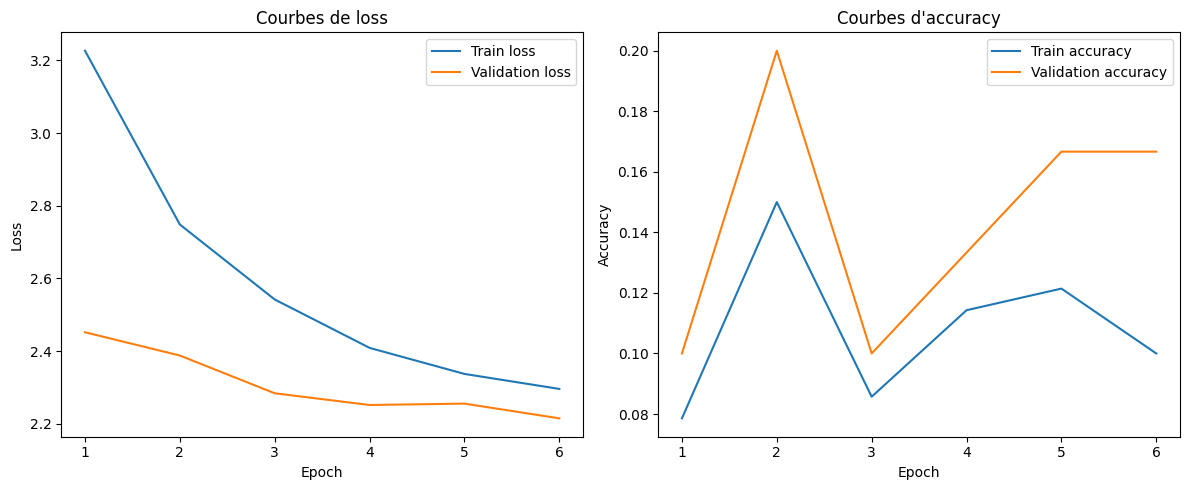

Figure sauvegardée : /content/drive/MyDrive/Projet_Deep_Learning_Musique/results/MLP_spectrogrammes_aplatis_curves.png

Expérience : CNN_LeNet_baseline
Epoch 01/15 | Train loss: 2.6143 | Val loss: 2.2911 | Val accuracy: 0.1667
Epoch 02/15 | Train loss: 2.2962 | Val loss: 2.2367 | Val accuracy: 0.1333
Epoch 03/15 | Train loss: 2.2280 | Val loss: 2.1198 | Val accuracy: 0.1000
Epoch 04/15 | Train loss: 2.1402 | Val loss: 1.9507 | Val accuracy: 0.2667
Epoch 05/15 | Train loss: 2.0323 | Val loss: 1.8108 | Val accuracy: 0.3667
Epoch 06/15 | Train loss: 1.9458 | Val loss: 1.7148 | Val accuracy: 0.3667
Epoch 07/15 | Train loss: 1.8465 | Val loss: 1.6233 | Val accuracy: 0.4333
Epoch 08/15 | Train loss: 1.8393 | Val loss: 1.5936 | Val accuracy: 0.3000
Epoch 09/15 | Train loss: 1.7049 | Val loss: 1.5949 | Val accuracy: 0.4000
Epoch 10/15 | Train loss: 1.5904 | Val loss: 1.4594 | Val accuracy: 0.4667
Epoch 11/15 | Train loss: 1.4762 | Val loss: 1.3601 | Val accuracy: 0.5000
Epoch 12/15 | Train los

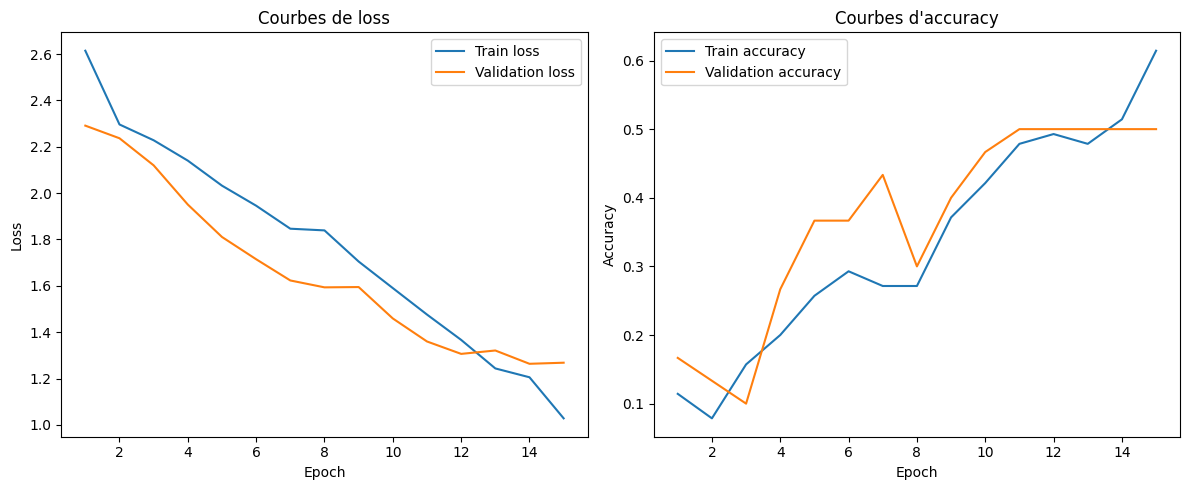

Figure sauvegardée : /content/drive/MyDrive/Projet_Deep_Learning_Musique/results/CNN_LeNet_baseline_curves.png

Expérience : CNN_padding_0
Epoch 01/15 | Train loss: 2.4655 | Val loss: 2.2987 | Val accuracy: 0.1000
Epoch 02/15 | Train loss: 2.3015 | Val loss: 2.2836 | Val accuracy: 0.2000
Epoch 03/15 | Train loss: 2.2799 | Val loss: 2.2395 | Val accuracy: 0.1000
Epoch 04/15 | Train loss: 2.2403 | Val loss: 2.2007 | Val accuracy: 0.1667
Epoch 05/15 | Train loss: 2.2151 | Val loss: 2.1386 | Val accuracy: 0.1333
Epoch 06/15 | Train loss: 2.1585 | Val loss: 2.1014 | Val accuracy: 0.1667
Early stopping après 6 epochs.


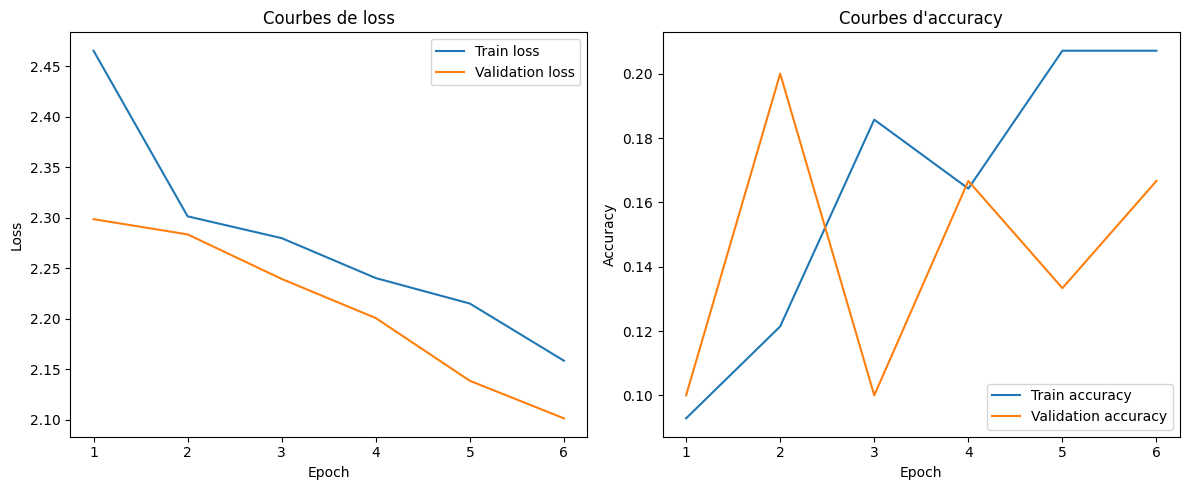

Figure sauvegardée : /content/drive/MyDrive/Projet_Deep_Learning_Musique/results/CNN_padding_0_curves.png

Expérience : CNN_padding_2
Epoch 01/15 | Train loss: 2.4280 | Val loss: 2.2621 | Val accuracy: 0.2333
Epoch 02/15 | Train loss: 2.2488 | Val loss: 2.1935 | Val accuracy: 0.1000
Epoch 03/15 | Train loss: 2.2128 | Val loss: 2.0753 | Val accuracy: 0.2000
Epoch 04/15 | Train loss: 2.0844 | Val loss: 1.9160 | Val accuracy: 0.1667
Epoch 05/15 | Train loss: 1.9193 | Val loss: 1.7874 | Val accuracy: 0.2667
Epoch 06/15 | Train loss: 1.8028 | Val loss: 1.7709 | Val accuracy: 0.2333
Epoch 07/15 | Train loss: 1.6091 | Val loss: 1.6044 | Val accuracy: 0.4000
Epoch 08/15 | Train loss: 1.3295 | Val loss: 1.5623 | Val accuracy: 0.4000
Epoch 09/15 | Train loss: 1.2495 | Val loss: 1.5125 | Val accuracy: 0.4333
Epoch 10/15 | Train loss: 0.9720 | Val loss: 1.4619 | Val accuracy: 0.4667
Epoch 11/15 | Train loss: 0.9903 | Val loss: 1.4577 | Val accuracy: 0.4333
Epoch 12/15 | Train loss: 0.8316 | Val lo

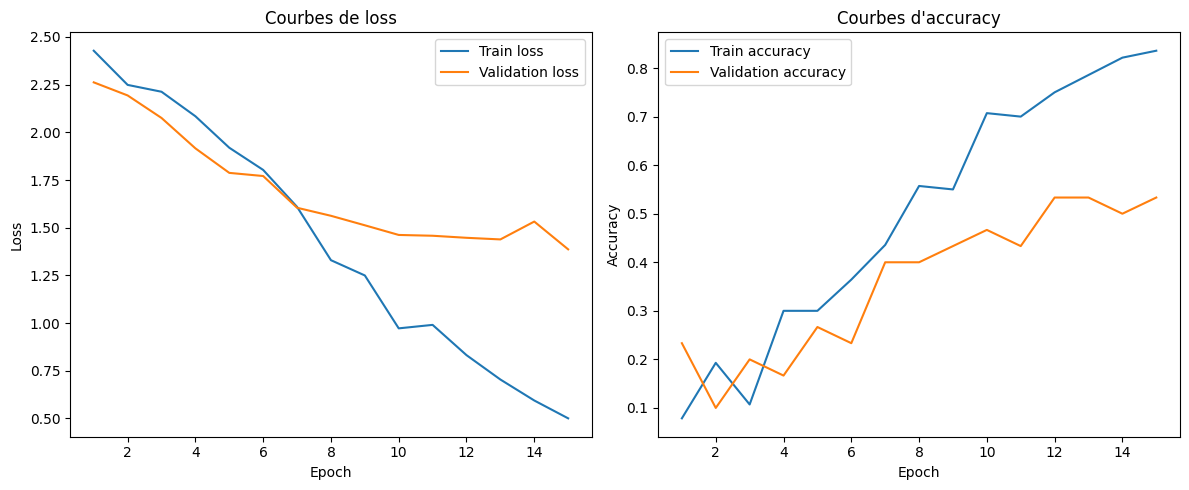

Figure sauvegardée : /content/drive/MyDrive/Projet_Deep_Learning_Musique/results/CNN_padding_2_curves.png

Expérience : CNN_max_pooling
Epoch 01/15 | Train loss: 2.6482 | Val loss: 2.2866 | Val accuracy: 0.1000
Epoch 02/15 | Train loss: 2.2969 | Val loss: 2.2881 | Val accuracy: 0.2000
Epoch 03/15 | Train loss: 2.2827 | Val loss: 2.2170 | Val accuracy: 0.1000
Epoch 04/15 | Train loss: 2.1998 | Val loss: 2.1130 | Val accuracy: 0.1333
Epoch 05/15 | Train loss: 2.1426 | Val loss: 2.0039 | Val accuracy: 0.2667
Epoch 06/15 | Train loss: 2.0077 | Val loss: 1.8199 | Val accuracy: 0.3333
Epoch 07/15 | Train loss: 1.8492 | Val loss: 1.6220 | Val accuracy: 0.3333
Epoch 08/15 | Train loss: 1.7189 | Val loss: 1.7024 | Val accuracy: 0.2667
Epoch 09/15 | Train loss: 1.6098 | Val loss: 1.4307 | Val accuracy: 0.5333
Epoch 10/15 | Train loss: 1.4508 | Val loss: 1.3430 | Val accuracy: 0.6000
Epoch 11/15 | Train loss: 1.3318 | Val loss: 1.3480 | Val accuracy: 0.4000
Epoch 12/15 | Train loss: 1.1219 | Val 

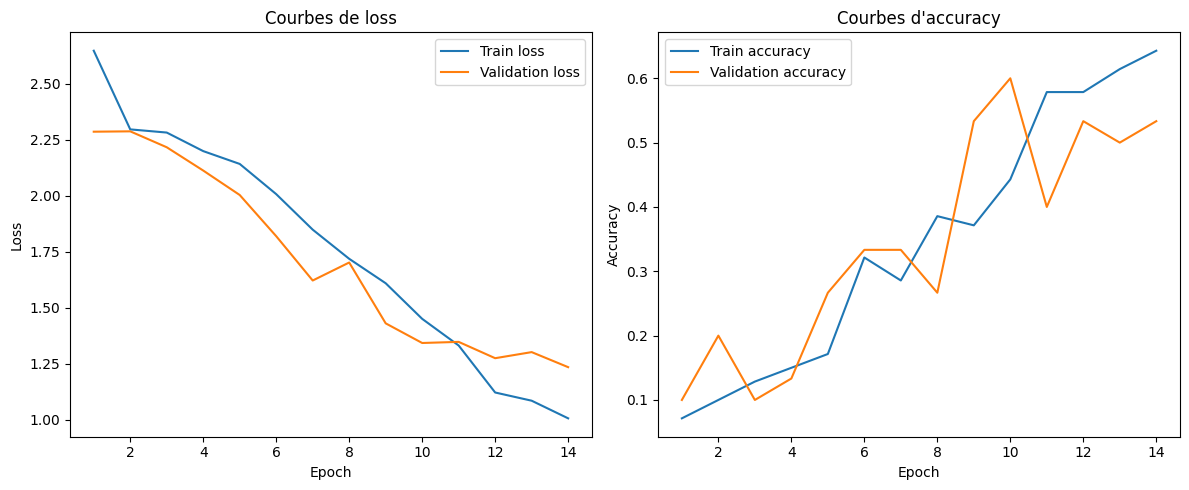

Figure sauvegardée : /content/drive/MyDrive/Projet_Deep_Learning_Musique/results/CNN_max_pooling_curves.png

Expérience : CNN_average_pooling
Epoch 01/15 | Train loss: 2.3518 | Val loss: 2.2928 | Val accuracy: 0.1333
Epoch 02/15 | Train loss: 2.2756 | Val loss: 2.1944 | Val accuracy: 0.1667
Epoch 03/15 | Train loss: 2.1813 | Val loss: 2.0029 | Val accuracy: 0.2000
Epoch 04/15 | Train loss: 2.0116 | Val loss: 1.7439 | Val accuracy: 0.3333
Epoch 05/15 | Train loss: 1.9285 | Val loss: 1.6630 | Val accuracy: 0.3333
Epoch 06/15 | Train loss: 1.8473 | Val loss: 1.6802 | Val accuracy: 0.4333
Epoch 07/15 | Train loss: 1.7771 | Val loss: 1.6069 | Val accuracy: 0.3333
Epoch 08/15 | Train loss: 1.6516 | Val loss: 1.5039 | Val accuracy: 0.3333
Epoch 09/15 | Train loss: 1.5756 | Val loss: 1.3679 | Val accuracy: 0.4667
Epoch 10/15 | Train loss: 1.4674 | Val loss: 1.3217 | Val accuracy: 0.4667
Epoch 11/15 | Train loss: 1.3075 | Val loss: 1.2953 | Val accuracy: 0.5333
Epoch 12/15 | Train loss: 1.2762 

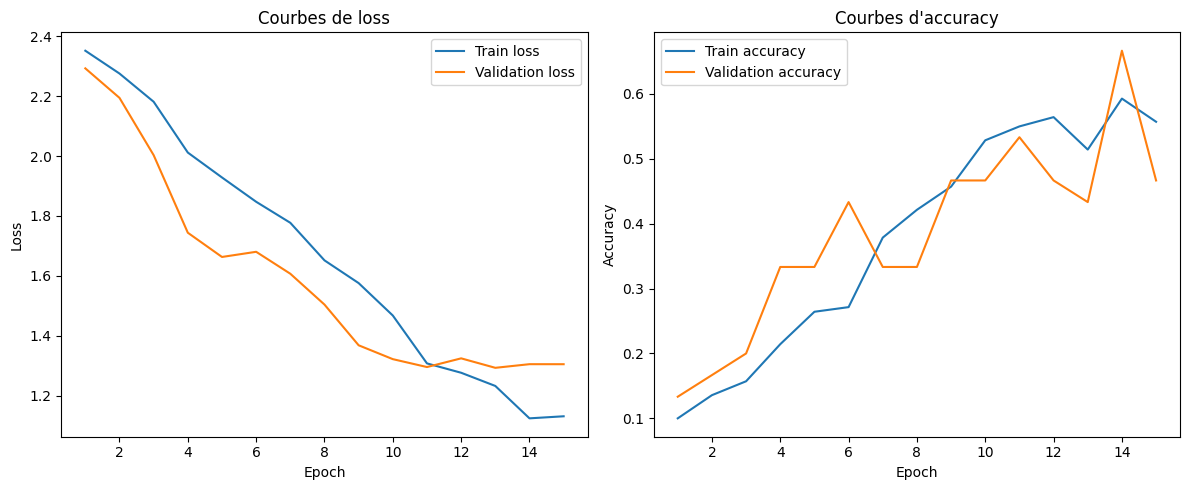

Figure sauvegardée : /content/drive/MyDrive/Projet_Deep_Learning_Musique/results/CNN_average_pooling_curves.png

Expérience : CNN_petit_nombre_filtres
Epoch 01/15 | Train loss: 2.5837 | Val loss: 2.3078 | Val accuracy: 0.1333
Epoch 02/15 | Train loss: 2.3219 | Val loss: 2.2935 | Val accuracy: 0.1000
Epoch 03/15 | Train loss: 2.3033 | Val loss: 2.2799 | Val accuracy: 0.1000
Epoch 04/15 | Train loss: 2.2844 | Val loss: 2.2555 | Val accuracy: 0.2333
Epoch 05/15 | Train loss: 2.2485 | Val loss: 2.2114 | Val accuracy: 0.2667
Epoch 06/15 | Train loss: 2.1745 | Val loss: 2.1300 | Val accuracy: 0.2000
Epoch 07/15 | Train loss: 2.1462 | Val loss: 2.0189 | Val accuracy: 0.2667
Epoch 08/15 | Train loss: 2.0631 | Val loss: 1.9083 | Val accuracy: 0.3333
Epoch 09/15 | Train loss: 1.9442 | Val loss: 1.8375 | Val accuracy: 0.2333
Epoch 10/15 | Train loss: 1.7793 | Val loss: 1.6983 | Val accuracy: 0.2667
Epoch 11/15 | Train loss: 1.7555 | Val loss: 1.6334 | Val accuracy: 0.5000
Epoch 12/15 | Train loss

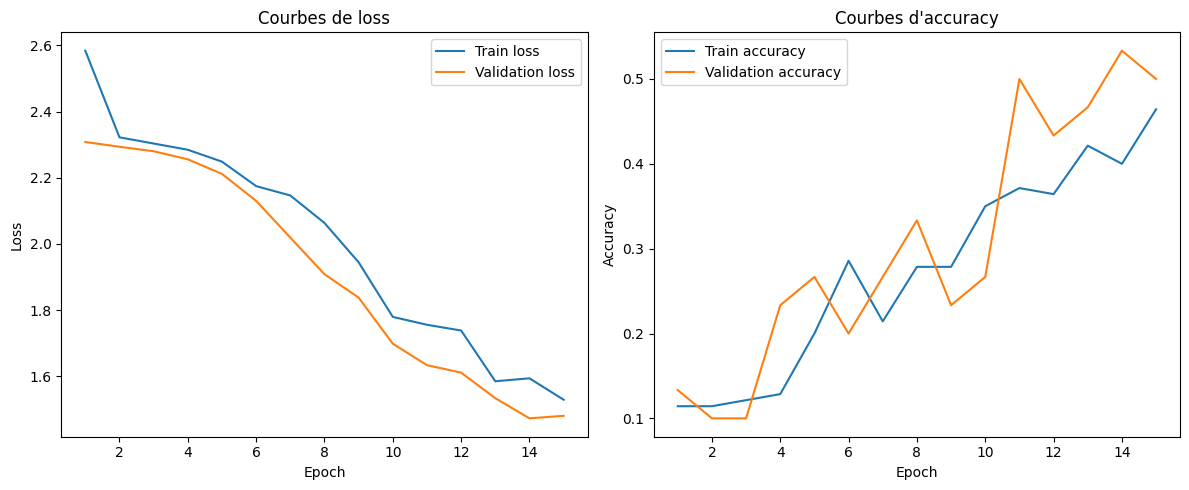

Figure sauvegardée : /content/drive/MyDrive/Projet_Deep_Learning_Musique/results/CNN_petit_nombre_filtres_curves.png

Expérience : CNN_avec_convolution_1x1
Epoch 01/15 | Train loss: 2.3806 | Val loss: 2.2870 | Val accuracy: 0.1000
Epoch 02/15 | Train loss: 2.2857 | Val loss: 2.2418 | Val accuracy: 0.1667
Epoch 03/15 | Train loss: 2.2377 | Val loss: 2.1170 | Val accuracy: 0.2000
Epoch 04/15 | Train loss: 2.1572 | Val loss: 1.9841 | Val accuracy: 0.2333
Epoch 05/15 | Train loss: 2.0688 | Val loss: 1.8426 | Val accuracy: 0.2000
Epoch 06/15 | Train loss: 1.9712 | Val loss: 1.9424 | Val accuracy: 0.3333
Epoch 07/15 | Train loss: 1.9265 | Val loss: 1.7967 | Val accuracy: 0.2333
Epoch 08/15 | Train loss: 1.8821 | Val loss: 1.7329 | Val accuracy: 0.3333
Epoch 09/15 | Train loss: 1.8818 | Val loss: 1.6058 | Val accuracy: 0.4000
Epoch 10/15 | Train loss: 1.7369 | Val loss: 1.5702 | Val accuracy: 0.3667
Epoch 11/15 | Train loss: 1.6617 | Val loss: 1.5400 | Val accuracy: 0.3333
Epoch 12/15 | Train

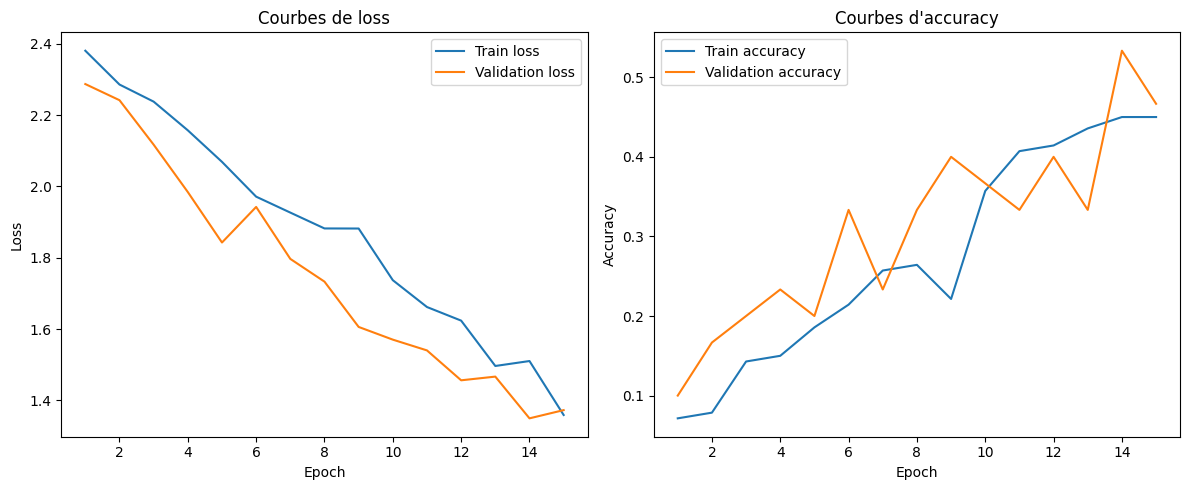

Figure sauvegardée : /content/drive/MyDrive/Projet_Deep_Learning_Musique/results/CNN_avec_convolution_1x1_curves.png
Tableau comparatif sauvegardé : /content/drive/MyDrive/Projet_Deep_Learning_Musique/results/cnn_experiments_results.csv


,model_name,final_train_loss,final_val_loss,best_val_loss,best_val_accuracy,best_epoch,trainable_parameters,training_time_seconds,model_path,curve_path,params
0,MLP_spectrogrammes_aplatis,2.295731,2.214725,2.387614,0.200000,2,4228746,2.724944,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,{}
1,CNN_LeNet_baseline,1.028541,1.268501,1.263836,0.500000,14,4208970,4.764845,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,{}
2,CNN_padding_0,2.158479,2.101430,2.283574,0.200000,2,3459402,1.734160,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,"{'padding': 0, 'stride': 1, 'pooling': 'max', ..."
3,CNN_padding_2,0.500130,1.386407,1.386407,0.533333,15,4208970,5.060526,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,"{'padding': 2, 'stride': 1, 'pooling': 'max', ..."
4,CNN_max_pooling,1.006555,1.235091,1.343041,0.600000,10,4208970,2.459263,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,"{'padding': 2, 'stride': 1, 'pooling': 'max', ..."
5,CNN_average_pooling,1.130852,1.304768,1.304857,0.666667,14,4208970,2.993456,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,"{'padding': 2, 'stride': 1, 'pooling': 'avg', ..."
6,CNN_petit_nombre_filtres,1.528874,1.480369,1.472695,0.533333,14,2101994,2.645030,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,"{'padding': 2, 'stride': 1, 'pooling': 'max', ..."
7,CNN_avec_convolution_1x1,1.358827,1.372501,1.349444,0.533333,14,4209242,2.745919,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,"{'padding': 2, 'stride': 1, 'pooling': 'max', ..."


In [ ]:
cnn_experiments = [
    {
        "name": "MLP_spectrogrammes_aplatis",
        "class": SpectrogramMLP,
        "params": {}
    },
    {
        "name": "CNN_LeNet_baseline",
        "class": LeNetSpectrogramCNN,
        "params": {}
    },
    {
        "name": "CNN_padding_0",
        "class": FlexibleSpectrogramCNN,
        "params": {"padding": 0, "stride": 1, "pooling": "max", "filters": (16, 32), "use_conv1x1": False}
    },
    {
        "name": "CNN_padding_2",
        "class": FlexibleSpectrogramCNN,
        "params": {"padding": 2, "stride": 1, "pooling": "max", "filters": (16, 32), "use_conv1x1": False}
    },
    {
        "name": "CNN_max_pooling",
        "class": FlexibleSpectrogramCNN,
        "params": {"padding": 2, "stride": 1, "pooling": "max", "filters": (16, 32), "use_conv1x1": False}
    },
    {
        "name": "CNN_average_pooling",
        "class": FlexibleSpectrogramCNN,
        "params": {"padding": 2, "stride": 1, "pooling": "avg", "filters": (16, 32), "use_conv1x1": False}
    },
    {
        "name": "CNN_petit_nombre_filtres",
        "class": FlexibleSpectrogramCNN,
        "params": {"padding": 2, "stride": 1, "pooling": "max", "filters": (8, 16), "use_conv1x1": False}
    },
    {
        "name": "CNN_avec_convolution_1x1",
        "class": FlexibleSpectrogramCNN,
        "params": {"padding": 2, "stride": 1, "pooling": "max", "filters": (16, 32), "use_conv1x1": True}
    }
]

criterion_cnn = nn.CrossEntropyLoss()
learning_rate_cnn = 0.001
num_epochs_cnn = 15
patience_cnn = 4

cnn_results = []

for experiment in cnn_experiments:
    experiment_name = experiment["name"]
    model_class = experiment["class"]
    model_params = experiment["params"]

    print("\n" + "=" * 70)
    print("Expérience :", experiment_name)
    print("=" * 70)

    model = model_class(num_classes=num_classes_cnn, **model_params)
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate_cnn)

    model_save_path = os.path.join(MODEL_DIR, f"{experiment_name}_best.pt")
    curve_save_path = os.path.join(RESULTS_DIR, f"{experiment_name}_curves.png")

    history, best_val_loss, best_val_accuracy, best_epoch, training_time = fit_model_cnn(
        model=model,
        train_loader=train_loader_cnn,
        val_loader=val_loader_cnn,
        criterion=criterion_cnn,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs_cnn,
        patience=patience_cnn,
        save_path=model_save_path
    )

    plot_training_curves_cnn(history, curve_save_path)

    cnn_results.append({
        "model_name": experiment_name,
        "final_train_loss": history["train_loss"][-1],
        "final_val_loss": history["val_loss"][-1],
        "best_val_loss": best_val_loss,
        "best_val_accuracy": best_val_accuracy,
        "best_epoch": best_epoch,
        "trainable_parameters": count_trainable_parameters(model),
        "training_time_seconds": training_time,
        "model_path": model_save_path,
        "curve_path": curve_save_path,
        "params": str(model_params)
    })

cnn_results_df = pd.DataFrame(cnn_results)

cnn_results_csv_path = os.path.join(RESULTS_DIR, "cnn_experiments_results.csv")
cnn_results_df.to_csv(cnn_results_csv_path, index=False)

print("Tableau comparatif sauvegardé :", cnn_results_csv_path)
display(cnn_results_df)

## 12. Évaluation finale du meilleur CNN

In [ ]:
cnn_only_results_df = cnn_results_df[
    cnn_results_df["model_name"] != "MLP_spectrogrammes_aplatis"
].copy()

best_cnn_index = cnn_only_results_df.sort_values(
    by=["best_val_accuracy", "best_val_loss"],
    ascending=[False, True]
).index[0]

best_cnn_row = cnn_results_df.loc[best_cnn_index]

print("Meilleur CNN :")
display(best_cnn_row)

best_cnn_name = best_cnn_row["model_name"]
best_cnn_path = best_cnn_row["model_path"]

experiment_config = next(
    experiment for experiment in cnn_experiments
    if experiment["name"] == best_cnn_name
)

best_cnn_model = experiment_config["class"](
    num_classes=num_classes_cnn,
    **experiment_config["params"]
)

best_cnn_model.load_state_dict(torch.load(best_cnn_path, map_location=device))
best_cnn_model = best_cnn_model.to(device)

test_loss_cnn, test_accuracy_cnn, test_predictions_cnn, test_labels_cnn = evaluate_cnn(
    best_cnn_model,
    test_loader_cnn,
    criterion_cnn,
    device
)

test_precision_cnn = precision_score(
    test_labels_cnn,
    test_predictions_cnn,
    average="macro",
    zero_division=0
)

test_recall_cnn = recall_score(
    test_labels_cnn,
    test_predictions_cnn,
    average="macro",
    zero_division=0
)

test_f1_cnn = f1_score(
    test_labels_cnn,
    test_predictions_cnn,
    average="macro",
    zero_division=0
)

print("Résultats du meilleur CNN sur le test set :")
print(f"Test loss      : {test_loss_cnn:.4f}")
print(f"Accuracy       : {test_accuracy_cnn:.4f}")
print(f"Precision macro: {test_precision_cnn:.4f}")
print(f"Recall macro   : {test_recall_cnn:.4f}")
print(f"F1-score macro : {test_f1_cnn:.4f}")

print("\nClassification report :")
print(
    classification_report(
        test_labels_cnn,
        test_predictions_cnn,
        target_names=label_encoder_cnn.classes_,
        zero_division=0
    )
)

Meilleur CNN :


,5
model_name,CNN_average_pooling
final_train_loss,1.130852
final_val_loss,1.304768
best_val_loss,1.304857
best_val_accuracy,0.666667
best_epoch,14
trainable_parameters,4208970
training_time_seconds,2.993456
model_path,/content/drive/MyDrive/Projet_Deep_Learning_Mu...
curve_path,/content/drive/MyDrive/Projet_Deep_Learning_Mu...


Résultats du meilleur CNN sur le test set :
Test loss      : 1.4197
Accuracy       : 0.4333
Precision macro: 0.4298
Recall macro   : 0.4333
F1-score macro : 0.3890

Classification report :
              precision    recall  f1-score   support

       blues       0.00      0.00      0.00         3
   classical       0.33      0.33      0.33         3
     country       0.00      0.00      0.00         3
       disco       0.43      1.00      0.60         3
      hiphop       0.75      1.00      0.86         3
        jazz       0.00      0.00      0.00         3
       metal       1.00      0.67      0.80         3
         pop       1.00      0.33      0.50         3
      reggae       0.29      0.67      0.40         3
        rock       0.50      0.33      0.40         3

    accuracy                           0.43        30
   macro avg       0.43      0.43      0.39        30
weighted avg       0.43      0.43      0.39        30



<Figure size 1000x800 with 0 Axes>

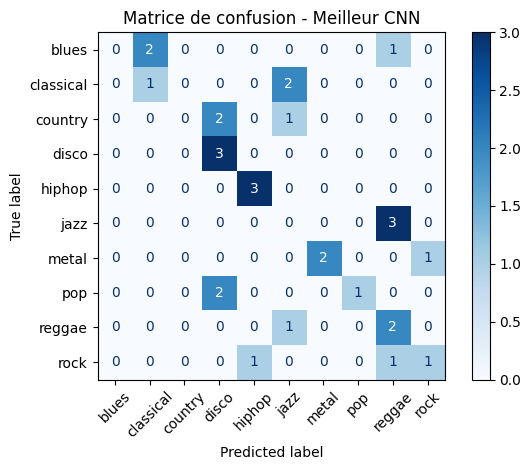

Matrice de confusion sauvegardée : /content/drive/MyDrive/Projet_Deep_Learning_Musique/results/cnn_gtzan_confusion_matrix.png


In [ ]:
cm_cnn = confusion_matrix(test_labels_cnn, test_predictions_cnn)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cnn,
    display_labels=label_encoder_cnn.classes_
)
disp.plot(cmap="Blues", xticks_rotation=45, values_format="d")
plt.title("Matrice de confusion - Meilleur CNN")
plt.tight_layout()

cnn_confusion_matrix_path = os.path.join(RESULTS_DIR, "cnn_gtzan_confusion_matrix.png")
plt.savefig(cnn_confusion_matrix_path, dpi=300)
plt.show()

print("Matrice de confusion sauvegardée :", cnn_confusion_matrix_path)

## 13. Visualisation de spectrogrammes et de cartes de caractéristiques

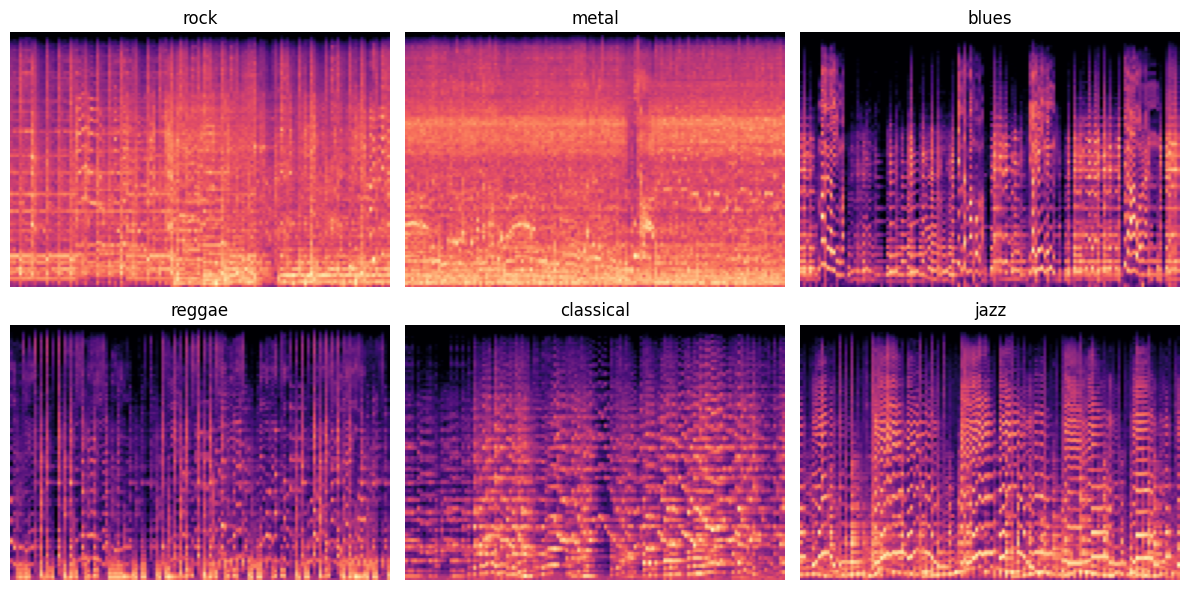

Visualisation sauvegardée : /content/drive/MyDrive/Projet_Deep_Learning_Musique/results/gtzan_spectrogram_examples.png


In [ ]:
def visualize_spectrogram_examples(dataset, label_encoder, save_path, n_examples=6):
    n_examples = min(n_examples, len(dataset))

    plt.figure(figsize=(12, 6))

    for i in range(n_examples):
        spectrogram, label = dataset[i]
        genre = label_encoder.inverse_transform([label.item()])[0]

        plt.subplot(2, 3, i + 1)
        plt.imshow(spectrogram.squeeze(0), cmap="magma", aspect="auto", origin="lower")
        plt.title(genre)
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

    print("Visualisation sauvegardée :", save_path)


spectrogram_examples_path = os.path.join(RESULTS_DIR, "gtzan_spectrogram_examples.png")

visualize_spectrogram_examples(
    dataset=test_dataset_cnn,
    label_encoder=label_encoder_cnn,
    save_path=spectrogram_examples_path,
    n_examples=6
)

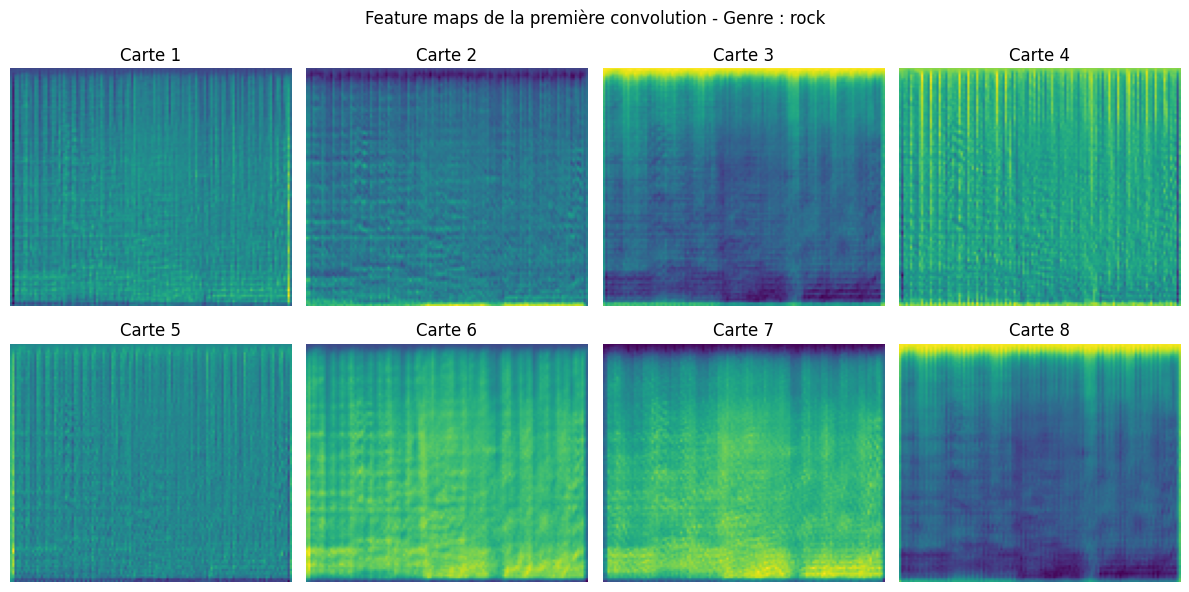

Feature maps sauvegardées : /content/drive/MyDrive/Projet_Deep_Learning_Musique/results/cnn_feature_maps_first_conv.png


In [ ]:
def find_first_conv_layer(model):
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            return module

    raise ValueError("Aucune couche Conv2d trouvée dans le modèle.")


def visualize_feature_maps(model, dataset, label_encoder, device, save_path, n_maps=8):
    model.eval()

    first_conv = find_first_conv_layer(model)

    spectrogram, label = dataset[0]
    genre = label_encoder.inverse_transform([label.item()])[0]

    x = spectrogram.unsqueeze(0).to(device)

    with torch.no_grad():
        feature_maps = first_conv(x)
        feature_maps = feature_maps.squeeze(0).cpu()

    n_maps = min(n_maps, feature_maps.shape[0])

    plt.figure(figsize=(12, 6))

    for i in range(n_maps):
        plt.subplot(2, 4, i + 1)
        plt.imshow(feature_maps[i], cmap="viridis", aspect="auto", origin="lower")
        plt.title(f"Carte {i + 1}")
        plt.axis("off")

    plt.suptitle(f"Feature maps de la première convolution - Genre : {genre}")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

    print("Feature maps sauvegardées :", save_path)


feature_maps_path = os.path.join(RESULTS_DIR, "cnn_feature_maps_first_conv.png")

visualize_feature_maps(
    model=best_cnn_model,
    dataset=test_dataset_cnn,
    label_encoder=label_encoder_cnn,
    device=device,
    save_path=feature_maps_path,
    n_maps=8
)

## 14. Squelette d'analyse à compléter

### Comparaison MLP vs CNN

Le MLP utilise les spectrogrammes aplatis, donc il perd la structure spatiale temps-fréquence.  
Le CNN conserve cette structure grâce aux convolutions et peut apprendre des motifs locaux plus pertinents.

À compléter avec les résultats obtenus :  
- Accuracy validation du MLP : ...
- Accuracy validation du CNN : ...
- Modèle le plus performant : ...

### Effet du padding

Le padding permet de conserver davantage d'information sur les bords du spectrogramme.  
Sans padding, les dimensions diminuent plus rapidement.

À compléter :  
- Résultat avec padding = 0 : ...
- Résultat avec padding = 2 : ...
- Interprétation : ...

### Effet du stride

Un stride plus grand réduit plus rapidement la taille des cartes de caractéristiques.  
Cela peut accélérer le calcul, mais aussi perdre de l'information.

À compléter :  
- Résultat observé : ...
- Interprétation : ...

### Effet du pooling

Le max pooling garde les activations les plus fortes.  
L'average pooling conserve une information moyenne locale.

À compléter :  
- Résultat avec max pooling : ...
- Résultat avec average pooling : ...
- Interprétation : ...

### Effet du nombre de filtres

Augmenter le nombre de filtres augmente la capacité du modèle, mais aussi le nombre de paramètres.

À compléter :  
- Petit CNN : ...
- CNN moyen : ...
- Interprétation : ...

### Effet de la convolution 1x1

La convolution 1x1 permet de combiner les canaux sans modifier directement la structure spatiale.

À compléter :  
- Résultat sans convolution 1x1 : ...
- Résultat avec convolution 1x1 : ...
- Interprétation : ...

### Interprétation des cartes de caractéristiques

Les cartes de caractéristiques montrent les zones du spectrogramme activées par les filtres de convolution.

À compléter :  
- Les cartes semblent détecter : ...
- Les zones importantes sont plutôt : ...

### Limites observées

Limites possibles :  
- Dataset relativement petit
- Risque de surapprentissage
- Spectrogrammes redimensionnés à taille fixe
- Mode rapide qui utilise seulement une partie des données
- Différences possibles selon les genres musicaux

### Réponse à la question de synthèse

Pourquoi un CNN est-il plus pertinent qu'un MLP pour une tâche de classification d'images sur un dataset réel, et comment les choix de padding, stride, pooling et profondeur influencent-ils réellement les performances du modèle ?

Réponse à compléter :

Un CNN est plus pertinent qu'un MLP pour classifier des images car il exploite la structure spatiale des données. Dans le cas des spectrogrammes, cette structure correspond aux relations entre le temps et les fréquences. Les convolutions permettent d'apprendre des motifs locaux, le partage des poids réduit le nombre de paramètres, et les couches de pooling rendent le modèle plus robuste.

Les choix d'architecture influencent directement les performances. Le padding contrôle la conservation des bords, le stride influence la réduction de dimension, le pooling résume l'information locale, et la profondeur ou le nombre de filtres augmente la capacité du modèle à apprendre des représentations plus complexes. Les résultats expérimentaux permettent de vérifier concrètement ces effets sur GTZAN.